<a href="https://colab.research.google.com/github/iNuman/PytorchDeepLearnignPlayGround/blob/main/PytorchPlayGround.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns

In [14]:
#%% data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()


,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


<Axes: xlabel='wt', ylabel='mpg'>

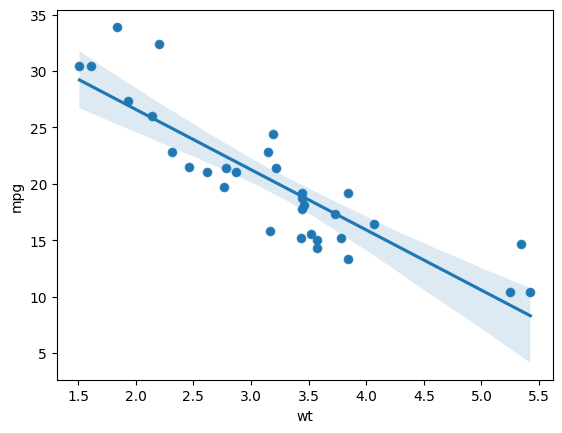

In [15]:
#%% visualise the model
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

# convert data to tensor

In [16]:
# X_list = cars.wt.values
# X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
# y_list = cars.mpg.values.tolist()
# y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)
# X = torch.from_numpy(X_np)
# y = torch.tensor(y_list)

X_np = cars.wt.values.astype(np.float32).reshape(-1,1)
y_np = cars.mpg.values.astype(np.float32).reshape(-1,1)

X = torch.from_numpy(X_np)
y = torch.from_numpy(y_np)

#training

In [29]:
import torch.optim as optim

# Parameters
w = torch.rand(1, requires_grad=True, dtype=torch.float32)
b = torch.rand(1, requires_grad=True, dtype=torch.float32)

# Optimizer
optimizer = optim.SGD([w, b], lr=1e-2)   # maybe lr=0.05
num_epochs = 3000
for epoch in range(num_epochs):
    # forward pass
    y_pred = X * w + b
    loss = torch.mean((y_pred - y)**2)  # MSE

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, w: {w.item():.4f}, b: {b.item():.4f}")

print(f"Final Weight: {w.item()}, Bias: {b.item()}")


Epoch 0, Loss: 354.5660, w: 1.7782, b: 0.3662
Epoch 50, Loss: 100.5370, w: 4.2362, b: 3.9261
Epoch 100, Loss: 87.5762, w: 3.5345, b: 6.3695
Epoch 150, Loss: 76.4445, w: 2.8842, b: 8.6339
Epoch 200, Loss: 66.8837, w: 2.2814, b: 10.7324
Epoch 250, Loss: 58.6722, w: 1.7229, b: 12.6773
Epoch 300, Loss: 51.6195, w: 1.2052, b: 14.4797
Epoch 350, Loss: 45.5622, w: 0.7255, b: 16.1500
Epoch 400, Loss: 40.3597, w: 0.2809, b: 17.6981
Epoch 450, Loss: 35.8914, w: -0.1311, b: 19.1327
Epoch 500, Loss: 32.0536, w: -0.5130, b: 20.4623
Epoch 550, Loss: 28.7575, w: -0.8668, b: 21.6945
Epoch 600, Loss: 25.9266, w: -1.1948, b: 22.8364
Epoch 650, Loss: 23.4951, w: -1.4988, b: 23.8947
Epoch 700, Loss: 21.4068, w: -1.7804, b: 24.8755
Epoch 750, Loss: 19.6132, w: -2.0415, b: 25.7844
Epoch 800, Loss: 18.0728, w: -2.2834, b: 26.6268
Epoch 850, Loss: 16.7497, w: -2.5076, b: 27.4075
Epoch 900, Loss: 15.6133, w: -2.7154, b: 28.1310
Epoch 950, Loss: 14.6373, w: -2.9080, b: 28.8015
Epoch 1000, Loss: 13.7991, w: -3.0

# check results

In [30]:
print(f"Weight: {w.item()}, Bias: {b.item()}")
y_pred = (X * w + b).detach().numpy()
y_pred

Weight: -5.236582279205322, Bias: 36.90946578979492


array([[23.189621],
       [21.854292],
       [24.760595],
       [20.073854],
       [18.895622],
       [18.790892],
       [18.214867],
       [20.204767],
       [20.41423 ],
       [18.895622],
       [18.895622],
       [15.596575],
       [17.377014],
       [17.115185],
       [ 9.417408],
       [ 8.506245],
       [ 8.919935],
       [25.388985],
       [28.452385],
       [27.300337],
       [24.001291],
       [18.476696],
       [18.921806],
       [16.800991],
       [16.774807],
       [26.77668 ],
       [25.703178],
       [28.986517],
       [20.3095  ],
       [22.404133],
       [18.214867],
       [22.351768]], dtype=float32)

# (Statistical) Linear Regression

Slope: [[-5.3444715]], Bias: [37.285126]


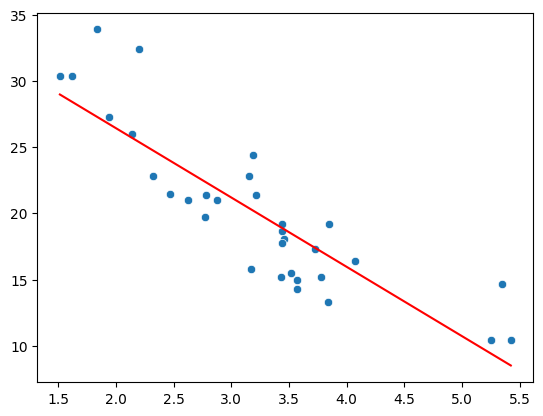

In [32]:
# Predictions
y_pred = (X * w + b).detach().numpy()

# Sort by X for a clean line
sorted_idx = np.argsort(X_np.flatten())
X_sorted = X_np.flatten()[sorted_idx]
y_pred_sorted = y_pred.flatten()[sorted_idx]

# Plot
sns.scatterplot(x=X_np.flatten(), y=y_np.flatten())
sns.lineplot(x=X_sorted, y=y_pred_sorted, color="red")

# %% (Statistical) Linear Regression
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_np, y_np)
print(f"Slope: {reg.coef_}, Bias: {reg.intercept_}")

In [20]:
!pip install torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

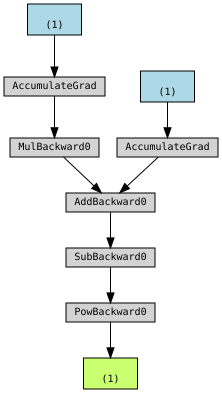

In [21]:
import os
from torchviz import make_dot
os.environ['PATH'] += os.pathsep + 'C:/Program Files (x86)/Graphviz/bin'
make_dot(loss_tensor)